# Crypto perpetuals: a design matrix that is mostly one number

A perpetual future has no expiry, so nothing forces its price to converge on spot. The exchange
uses a **funding rate** instead: when the perpetual trades above spot, longs pay shorts, and the
payment scales with the gap. That gap - the **premium** - is the central quantity in this case
study, and the feature set is built largely out of it. More than half the columns carry
`premium` in the name: its level, its change over six horizons, its volatility over four, its
z-score over two windows, its quantile position over three, its rank and its cross-sectional
z-score. Six more describe the funding rate the premium produces. The remainder are a handful of
volatility estimates and two regime probabilities.

So this design matrix is not merely collinear - it is one economic quantity measured many ways,
with a small number of columns describing anything else. That makes it the clearest case in the
nine for asking what a penalty actually does. **Regularization** adds a penalty on coefficient
size to the fitting objective, and the two shapes it can take pull in opposite directions here.
**Ridge** spreads weight across the whole premium block, which is close to averaging many
measurements of the same thing. **Lasso** keeps a few columns and zeros the rest, which on a
block of near-duplicates means choosing among measurements that carry the same information - and
as the penalty rises, eventually leaving the block altogether.

Two folds, not eight: the usable history of liquid perpetual funding data is short, and
`05_evaluation` set the walk-forward schedule from what exists rather than from what would be
convenient. Every result below rests on two validation years.

**Learning objectives.** By the end of this notebook you will be able to:

- Read the set of models a case study has declared for a label, and say which estimator and
  which hyperparameters each declared name resolves to.
- Bind those declarations to the data on disk and check, before anything is fitted, that every
  configuration will be measured on the same symbols, the same dates and the same folds.
- Fit a population of models on walk-forward folds and publish one complete set of validation
  predictions per configuration.
- Read back the coefficients a run stored, count how many are non-zero along an L1 penalty
  path, and recognise the point where the path has reduced to a single column.
- Read a stable negative information coefficient for what it is - a relationship whose sign
  the training window fitted opposite to the way the validation period paid - rather than as
  an absence of one.
- Run configurations of your own into a private copy of the run log, and have them compared on
  the same footing as the ones shipped here.

**Book reference**: Chapter 11 (The ML Pipeline). Chapter 6, Section 6.7 (Search accounting and
run logging) introduces the run log this notebook writes to.

**Prerequisites**: [`03_financial_features`](03_financial_features.ipynb) and
[`04_model_based_features`](04_model_based_features.ipynb) have written the feature matrices,
and [`05_evaluation`](05_evaluation.ipynb) has established the walk-forward folds.

**What it writes**: one training run and one complete validation prediction set per
configuration, in `run_log/registry.db` and under `run_log/training/` and
`run_log/predictions/`, grouped under a named population.
[`13_backtest`](13_backtest.ipynb) reads that population, runs every member against the
equal-weight baseline, and selects on validation backtest Sharpe. **Selection happens there,
not here.** This notebook ranks configurations by information coefficient to show what
regularization does to a redundant feature set; that ranking decides nothing.

In [1]:
"""Fit the declared crypto perpetuals linear-model population on the walk-forward folds."""

import re

import numpy as np
import plotly.graph_objects as go
import polars as pl

from case_studies.research import (
    Result,
    declared_labels,
    load_model_configs,
    model_requests,
    open_study,
    resolved_model_plan,
    run_model_population,
)
from utils.style import COLORS, show_plotly_with_alt

In [2]:
LABEL = "fwd_ret_8h"
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""
PREVIEW_REDUCTIONS: dict = {}
CONFIG_NAMES: list[str] = []
POPULATION_NAME = "crypto_perps_funding-linear-validation-v1"

In [3]:
study = open_study(
    "crypto_perps_funding", execution_tier=EXECUTION_TIER, workspace=WORKSPACE or None
)

## 1. Which label, and which models

A label is the thing being predicted. This case study defines four in `config/setup.yaml`.
`fwd_ret_8h`, the return over the funding interval after the decision time, is the primary one -
the horizon the strategy chapters trade, and the one that lines up with when funding is actually
paid. `fwd_ret_24h` is the same idea over three intervals, and `fwd_dir_8h` and `fwd_dir_8h_3c`
are classification variants that ask for the direction rather than the size of the move.

**This notebook fits one label per run.** `LABEL` above selects it, and every choice below
follows from that one setting, because each label has its own training menu at
`config/training/{label}.yaml`. The menu lists, family by family, the named configurations to
fit for that label. A label with no menu file has nothing declared and nothing to fit; these
are the ones that declare linear models.

In [4]:
declared_labels(study, "linear")

('fwd_dir_8h', 'fwd_dir_8h_3c', 'fwd_ret_24h', 'fwd_ret_8h')

Each name in the menu resolves to a preset file in the shared directory
`case_studies/config/{model_type}/`, which holds that configuration's hyperparameters. The
frame below is the menu for `LABEL`, with each name resolved to the estimator class it names
and the arguments that class is constructed with. To change what runs, edit the menu or the
presets rather than this notebook.

The grid covers the two shapes a penalty can take:

- **Ridge** penalizes the sum of squared coefficients. It shrinks correlated coefficients
  towards each other and keeps every feature, at a strength set by `alpha`. The grid steps
  `alpha` by powers of ten across ten orders of magnitude, because the useful value depends on
  the scale and the collinearity of the design matrix and neither is known in advance.
- **Lasso** penalizes the sum of absolute coefficients, which drives some of them exactly to
  zero: it selects features rather than shrinking them. **ElasticNet** mixes the two.

Lasso and ElasticNet are parameterized here by `alpha_frac` rather than a raw penalty. For any
fold there is a threshold penalty $\alpha_{\max}$ - the smallest one that zeros every
coefficient - which is computed from that fold's own data. `alpha_frac` is the fraction of it
to apply, so one declared `alpha_frac` means the same thing on every fold, while a fixed raw
penalty would mean something different on each. It is also what makes the L1 grid readable as a
path: the configurations are ordered by how far along the way to total suppression they go.

In [5]:
configs = load_model_configs(
    study,
    "linear",
    labels=[LABEL],
    config_names=CONFIG_NAMES or None,
)
configs

family,label,config_name,model_class,params
str,str,str,str,str
"""linear""","""fwd_ret_8h""","""ols""","""LinearRegression""","""defaults"""
"""linear""","""fwd_ret_8h""","""ridge_a0.001""","""Ridge""","""alpha=0.001"""
"""linear""","""fwd_ret_8h""","""ridge_a0.01""","""Ridge""","""alpha=0.01"""
"""linear""","""fwd_ret_8h""","""ridge_a0.1""","""Ridge""","""alpha=0.1"""
"""linear""","""fwd_ret_8h""","""ridge_a1.0""","""Ridge""","""alpha=1.0"""
…,…,…,…,…
"""linear""","""fwd_ret_8h""","""enet_f0.03""","""ElasticNet""","""alpha_frac=0.03, l1_ratio=0.5,…"
"""linear""","""fwd_ret_8h""","""enet_f0.015""","""ElasticNet""","""alpha_frac=0.015, l1_ratio=0.5…"
"""linear""","""fwd_ret_8h""","""enet_f0.35""","""ElasticNet""","""alpha_frac=0.35, l1_ratio=0.5,…"


## 2. Binding the declarations to the data

A menu entry says which estimator to fit. It does not say which feature columns exist today,
where the walk-forward folds fall, or which symbol-time pairs have both a feature row and a
label. **Resolving** a request is the step that goes and finds all of that: it reads the label
and feature files, computes the fold boundaries from the walk-forward parameters in
`config/setup.yaml`, works out the exact set of rows each fit is expected to predict, and turns
any data-dependent hyperparameter into the number it will actually use - each fold's own
$\alpha_{\max}$ times `alpha_frac`, in the case of Lasso.

Resolving reads the inputs and fits nothing, so the plan below can be inspected before any
computation starts. The three things to check in it:

- **`feature_count`, `eligible_entities` and `eligible_rows` agree across every row.** They are
  the width of the design matrix, the number of perpetual contracts, and the number of
  symbol-time pairs to be predicted. Every configuration here reads the same feature matrix, so
  a row that differs is a configuration being measured on a different sample from its
  neighbours, and its results are not comparable with theirs.
- **`folds` is the same everywhere**, and equals the number of walk-forward splits
  `05_evaluation` established.
- **`validation_start` and `validation_end` bracket the development sample.** The held-out tail
  must not appear here: it is scored once, at the end of the case study, and any of it visible
  in this window would mean it had been used to choose something.

Each row also carries a `training_hash`: the identity of that computation, derived from
everything that can change its result. [`RUN_LOG.md`](../RUN_LOG.md#identity) sets out what goes
into one and what follows from it.

In [6]:
requests = model_requests(
    study,
    configs,
    execution_tier=EXECUTION_TIER,
    preview_reductions=PREVIEW_REDUCTIONS,
)
resolved = tuple(request.resolve() for request in requests)

plan = resolved_model_plan(resolved)
plan.select(
    "config_name",
    "feature_count",
    "eligible_entities",
    "eligible_rows",
    "folds",
    "validation_start",
    "validation_end",
)

config_name,feature_count,eligible_entities,eligible_rows,folds,validation_start,validation_end
str,i64,i64,i64,i64,"datetime[μs, UTC]","datetime[μs, UTC]"
"""enet_f0.015""",44,19,35280,2,2022-01-01 00:00:00 UTC,2023-12-31 08:00:00 UTC
"""enet_f0.03""",44,19,35280,2,2022-01-01 00:00:00 UTC,2023-12-31 08:00:00 UTC
"""enet_f0.08""",44,19,35280,2,2022-01-01 00:00:00 UTC,2023-12-31 08:00:00 UTC
"""enet_f0.2""",44,19,35280,2,2022-01-01 00:00:00 UTC,2023-12-31 08:00:00 UTC
"""enet_f0.35""",44,19,35280,2,2022-01-01 00:00:00 UTC,2023-12-31 08:00:00 UTC
…,…,…,…,…,…,…
"""ridge_a1000.0""",44,19,35280,2,2022-01-01 00:00:00 UTC,2023-12-31 08:00:00 UTC
"""ridge_a10000.0""",44,19,35280,2,2022-01-01 00:00:00 UTC,2023-12-31 08:00:00 UTC
"""ridge_a100000.0""",44,19,35280,2,2022-01-01 00:00:00 UTC,2023-12-31 08:00:00 UTC


## 3. Fitting the population

`run_model_population` fits every resolved request. For one request it walks the folds, and on
each one:

1. takes the rows inside that fold's training window,
2. fills missing feature values with the training window's median for that column, then
   standardizes each column to zero mean and unit variance - both fitted on training rows only
   and then applied to the validation rows, so nothing from the validation window reaches the
   fit,
3. fits the estimator with that fold's resolved parameters,
4. predicts the fold's validation rows.

The fold predictions are concatenated into one series covering the whole validation period,
which is what a walk-forward prediction set is: each date predicted by a model that saw only
data before it. The run then writes a `training_runs` row and the fitted coefficients, a
`prediction_sets` row and the predictions themselves, and the metrics computed from them. It
does this per configuration rather than once at the end, so an interruption costs the
configuration in flight and nothing else.

Every case study that fits linear models calls this same runner, which is what makes their
results comparable. Unlike gradient boosting or a neural network, a linear model has no
intermediate states worth scoring: there is one fit and therefore one checkpoint per
configuration, and no learning curve to plot.

**What the call publishes is a population**: a named, immutable list of the prediction sets it
is going to produce. The list is computed from the resolved specifications before the first fit
and written down, and afterwards every member must exist and be complete. That is what makes
the downstream comparison well defined - `13_backtest` backtests this population, not whatever
predictions happen to be in the registry - and it is why a configuration that raises fails the
whole call rather than publishing a population one member short. Everything that finished stays
registered, and re-running fits only what is missing.

In [7]:
execution, population = run_model_population(study, resolved, population_name=POPULATION_NAME)

fitted = sum(len(item["fitted_folds"]) for item in execution.diagnostics)
reused = sum(len(item["reused_folds"]) for item in execution.diagnostics)
print(f"{len(execution.runs)} configurations: {fitted} folds fitted, {reused} reused")
print(f"population {population.name}: {len(population.members)} prediction sets")

28 configurations: 0 folds fitted, 56 reused
population crypto_perps_funding-linear-validation-v1: 28 prediction sets


`reused` is not zero on a second run. Every identity is re-derived from the inputs, the
registry already holds the matching rows, and the runner returns the stored result rather than
fitting again - so re-running this notebook unchanged costs the time it takes to read the data.

### Running configurations of your own

The published run log is read-only. To add runs, open the study against a workspace, which
holds its own registry and artifacts and reads the same labels and features:

```python
study = open_study("crypto_perps_funding", workspace="~/ml4t-experiments")
configs = load_model_configs(
    study, "linear", labels=["fwd_ret_8h"], config_names=["ols", "ridge_a1.0", "ridge_a3.0"]
)
requests = model_requests(study, configs)
resolved = tuple(request.resolve() for request in requests)
execution, population = run_model_population(study, resolved, population_name="my-linear-v1")
```

`CONFIG_NAMES` fits a subset of what the menu already declares; a name the menu does not
declare raises rather than quietly fitting fewer models than you asked for. To fit something
new, add a preset at `case_studies/config/ridge/ridge_a3.0.yaml` and list `ridge_a3.0` under
`linear:` in the label's menu. Editing an existing preset changes that configuration's
identity, so its result registers as a new row beside the old one instead of replacing it.

Give the run its own `population_name`: a name refers to one set of members permanently, and
reusing it for a different set raises. Everything downstream reads the registry rather than the
notebook, so predictions produced this way are selected and backtested on the same footing as
the ones shipped here, inside your workspace.
[`RUN_LOG.md`](../RUN_LOG.md#running-your-own-configurations) covers the rest, including how to
rehearse on a reduced universe first.

## 4. What came out

One row per configuration, read back from the registry. `ic_mean` is the **information
coefficient**: at each validation timestamp, rank the contracts by the model's prediction, rank
them by the return they went on to earn, correlate the two rankings, and average that
correlation over the validation period. It measures whether the model ranks contracts correctly,
on a scale where zero is no relationship, positive means the ranking points the right way, and
negative means it points the wrong way.

`ic_n_days` is how many validation timestamps produced a defined correlation. A model whose
coefficients collapse to nothing predicts the same value for every contract, and a constant has
no rank correlation with anything, so those timestamps would contribute nothing and the
configuration's IC would be an average over a smaller sample than its neighbours'.
`full_coverage` marks the configurations measured on all of them.

`auc_mean_daily` reads the same predictions as a classifier would. At each timestamp, take every
pair of one contract that went up and one that went down, and count the fraction of those pairs
the model ranked in the right order; average that over the validation period. One half is the
value a coin achieves. It is computed within each timestamp and then averaged, the same shape as
`ic_mean`, so the two are comparable: pooling every contract-timestamp pair into one curve
instead would also pay the model for the whole market moving in a direction it happened to lean.

Both readings are shown because the model here is fitted to the size of the return and this one
is not. `fwd_dir_8h` is the direction cut from the same return at the same horizon, and it is
what `07_gbm` fits a classifier to. Scoring this regression against it puts the two formulations
on one scale, so the question of whether predicting direction is easier than predicting size can
be answered from measurements rather than asserted.

In [8]:
catalog = (
    execution.catalog_rows.select(
        "config_name",
        "label",
        "complete",
        "ic_mean",
        "ic_std",
        "ic_n_days",
        "auc_mean_daily",
        "auc_n_days",
        "n_folds",
        "training_hash",
        "prediction_hash",
    )
    .sort("ic_mean", descending=True)
    .join(configs.select("config_name", "model_class", "params"), on="config_name", how="left")
)

if catalog.filter(~pl.col("complete")).height:
    raise RuntimeError("linear execution returned a partial prediction set")

full_days = int(catalog.get_column("ic_n_days").max())
catalog = catalog.with_columns(full_coverage=pl.col("ic_n_days") == full_days)
catalog.select(
    "config_name",
    "model_class",
    "params",
    "ic_mean",
    "ic_std",
    "ic_n_days",
    "auc_mean_daily",
    "full_coverage",
)

config_name,model_class,params,ic_mean,ic_std,ic_n_days,auc_mean_daily,full_coverage
str,str,str,f64,f64,f64,f64,bool
"""enet_f0.015""","""ElasticNet""","""alpha_frac=0.015, l1_ratio=0.5…",0.000838,0.008022,2189.0,0.509381,true
"""lasso_f0.015""","""Lasso""","""alpha_frac=0.015, max_iter=500…",0.000823,0.007894,2189.0,0.509318,true
"""ridge_a1000.0""","""Ridge""","""alpha=1000.0""",0.000281,0.0071,2189.0,0.508557,true
"""ridge_a10000000.0""","""Ridge""","""alpha=10000000.0""",0.000019,0.007406,2189.0,0.501036,true
"""ridge_a100.0""","""Ridge""","""alpha=100.0""",-0.001365,0.004244,2189.0,0.508458,true
…,…,…,…,…,…,…,…
"""enet_f0.5""","""ElasticNet""","""alpha_frac=0.5, l1_ratio=0.5, …",-0.04267,0.010766,2189.0,0.488646,true
"""enet_f0.7""","""ElasticNet""","""alpha_frac=0.7, l1_ratio=0.5, …",-0.042747,0.010688,2189.0,0.488472,true
"""lasso_f0.7""","""Lasso""","""alpha_frac=0.7, max_iter=5000""",-0.042747,0.010688,2189.0,0.488472,true


### How the penalty grid ranks

Only the configurations measured on all `full_days` validation timestamps are charted. The zero
line is the reference that matters: a bar below it is a model whose ranking pointed the wrong
way out of sample.

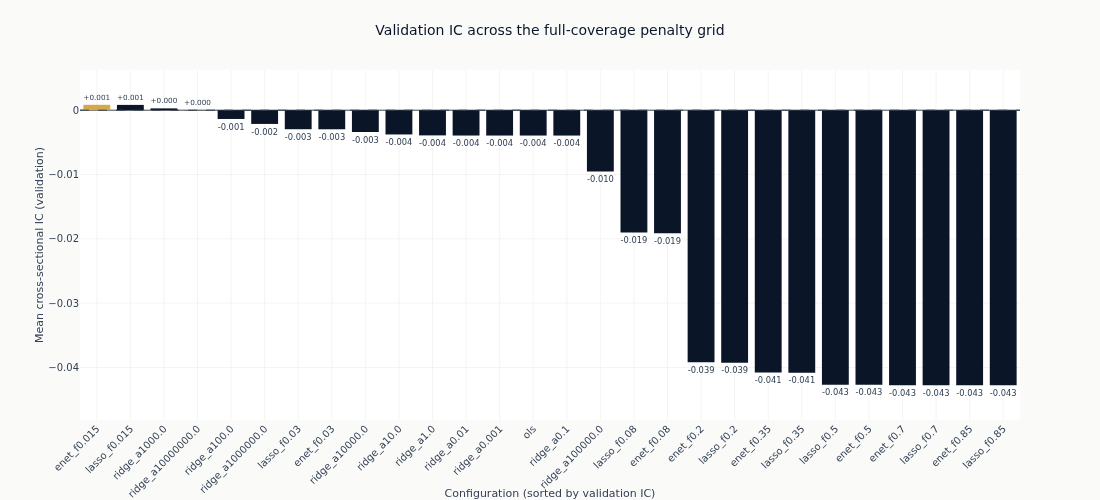

In [9]:
def compact(params: str) -> str:
    """Render declared parameters for a label: `alpha=1000000.0` reads as `alpha=1e+06`."""
    return re.sub(r"\d+\.?\d*(?:[eE][+-]?\d+)?", lambda m: f"{float(m.group()):g}", params)


full = catalog.filter("full_coverage")
leader = full.row(0, named=True)

fig_ic = go.Figure(
    go.Bar(
        x=full.get_column("config_name").to_list(),
        y=full.get_column("ic_mean").to_list(),
        marker_color=[
            COLORS["amber"] if name == leader["config_name"] else COLORS["blue"]
            for name in full.get_column("config_name")
        ],
        text=[f"{value:+.3f}" for value in full.get_column("ic_mean")],
        textposition="outside",
        cliponaxis=False,
    )
)
fig_ic.add_hline(y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"])
fig_ic.update_layout(
    title="Validation IC across the full-coverage penalty grid",
    height=500,
    width=1100,
    showlegend=False,
    margin=dict(t=70),
)
fig_ic.update_xaxes(title_text="Configuration (sorted by validation IC)", tickangle=-45)
fig_ic.update_yaxes(title_text="Mean cross-sectional IC (validation)")
show_plotly_with_alt(
    fig_ic,
    "Bar chart of mean validation information coefficient for every full-coverage linear "
    f"configuration, sorted descending, against a dashed zero line. {leader['config_name']} "
    f"({compact(leader['params'])}) is highlighted in amber at the top of the ranking at IC "
    f"{leader['ic_mean']:+.3f}. The L1 configurations form a long tail below zero that flattens "
    "at the aggressive end.",
)

### How much of the design matrix the penalty leaves standing

The L1 grid is a path: each `alpha_frac` suppresses more coefficients than the one before it.
Counting the non-zero coefficients turns the grid into a picture of what the penalty did to the
design matrix, and it is what makes the ranking above readable. The counts come from the
coefficients each run stored, read back through `fitted_states()`, so this is what was fitted
rather than what the configuration asked for. The name printed beside each count is the feature
carrying the largest absolute coefficient on the first fold.

In [10]:
l1 = (
    catalog.filter(pl.col("model_class").is_in(["Lasso", "ElasticNet"]))
    .with_columns(alpha_frac=pl.col("config_name").str.extract(r"_f([0-9.]+)$").cast(pl.Float64))
    .drop_nulls("alpha_frac")
    .sort("alpha_frac")
)

surviving, dominant = [], []
for row in l1.iter_rows(named=True):
    states = Result.open(study, row["training_hash"]).fitted_states()
    counts = [int(np.count_nonzero(state["model"].coef_)) for state in states]
    surviving.append(sum(counts) / len(counts))
    first = states[0]
    coefficients = np.asarray(first["model"].coef_).ravel()
    dominant.append(
        first["feature_names"][int(np.argmax(np.abs(coefficients)))] if counts[0] else "none"
    )

l1 = l1.with_columns(surviving_features=pl.Series(surviving), dominant_feature=pl.Series(dominant))
l1.select(
    "config_name", "model_class", "alpha_frac", "surviving_features", "dominant_feature", "ic_mean"
)

config_name,model_class,alpha_frac,surviving_features,dominant_feature,ic_mean
str,str,f64,f64,str,f64
"""enet_f0.015""","""ElasticNet""",0.015,33.0,"""garch_cond_vol""",0.000838
"""lasso_f0.015""","""Lasso""",0.015,32.0,"""garch_cond_vol""",0.000823
"""lasso_f0.03""","""Lasso""",0.03,26.5,"""garch_cond_vol""",-0.00296
"""enet_f0.03""","""ElasticNet""",0.03,27.5,"""garch_cond_vol""",-0.002967
"""lasso_f0.08""","""Lasso""",0.08,17.0,"""garch_cond_vol""",-0.019028
…,…,…,…,…,…
"""enet_f0.5""","""ElasticNet""",0.5,2.5,"""garch_cond_vol""",-0.04267
"""enet_f0.7""","""ElasticNet""",0.7,1.0,"""garch_cond_vol""",-0.042747
"""lasso_f0.7""","""Lasso""",0.7,1.0,"""garch_cond_vol""",-0.042747


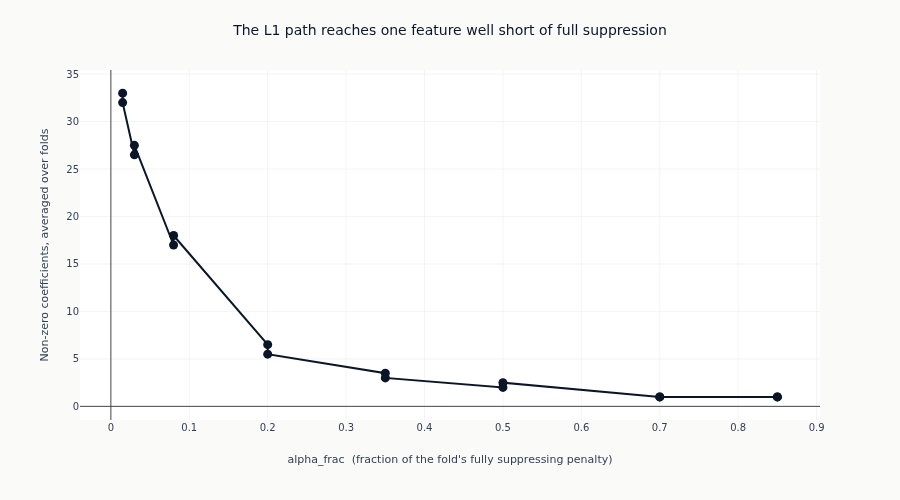

In [11]:
fig_path = go.Figure(
    go.Scatter(
        x=l1.get_column("alpha_frac").to_list(),
        y=l1.get_column("surviving_features").to_list(),
        mode="lines+markers",
        line=dict(color=COLORS["blue"], width=2),
        marker=dict(size=9, color=COLORS["blue"]),
    )
)
fig_path.update_layout(
    title="The L1 path reaches one feature well short of full suppression",
    height=500,
    width=900,
    showlegend=False,
    margin=dict(t=70),
)
fig_path.update_xaxes(title_text="alpha_frac  (fraction of the fold's fully suppressing penalty)")
fig_path.update_yaxes(title_text="Non-zero coefficients, averaged over folds")
show_plotly_with_alt(
    fig_path,
    "Line chart of the average number of non-zero coefficients against alpha_frac for the Lasso "
    "and ElasticNet configurations. The count falls steeply from the weakest penalty and "
    "flattens close to one across the aggressive end of the grid, well before alpha_frac reaches "
    "the value that would zero every coefficient.",
)

## 5. What to notice

**The L1 path reduces to one column, and the ranking stops moving exactly where it does.** Past
the middle of the `alpha_frac` grid the non-zero coefficient count reaches one, and from there
the information coefficient is identical across configurations. That is the mechanical signature
of a path that has run out: once a single coefficient is left, more penalty scales it without
changing the order it induces, and a rank correlation only sees the order. The flat tail is not
several configurations agreeing, it is one model reported several times - and reading it as
agreement is the mistake the coefficient count is here to prevent.

**The column it keeps is not a premium column.** With one coefficient left, what remains is a
volatility estimate rather than any of the many measurements of the premium. Read against the
framing at the top, that is the informative part. The premium block is wide but internally
redundant, so no single member of it stands out as a column, and a penalty that has to choose
exactly one goes elsewhere. Ridge, which spreads weight across the block instead of choosing
within it, does not face that choice and does not show the same reduction.

**A stable negative information coefficient is a relationship, not the absence of one.** The
single-column configurations post the largest-magnitude IC anywhere in this grid, on the wrong
side of zero, across every validation timestamp. The reading is that the remaining column does
order the cross-section - the training window simply fitted the sign opposite to the way the
validation period paid. Whether that is a genuine reversal or an artifact of two folds is
not something this notebook can settle, and it is the kind of question
[`11_causal_dml`](11_causal_dml.ipynb) exists for. What it does settle is that "the model found
nothing" would be the wrong summary.

**Nothing here reaches a size worth acting on.** The top of the grid sits a small fraction of a
percent above zero on two folds of validation data, and most of the grid sits below it. The
comparison that matters is against zero and against the equal-weight baseline, not against the
rest of the grid.

**None of this selects anything.** IC measures whether predictions rank contracts correctly, not
whether a strategy trading them makes money after costs and funding. Those are unusually far
apart in this case study: funding is a cash flow the holder receives or pays regardless of what
the price does, so a position can pay while its price prediction is wrong. Selection is on
validation backtest Sharpe over the population this notebook just published, and it happens in
[`13_backtest`](13_backtest.ipynb).

**Known limitations.** Two folds is few, and every statement above rests on two validation years
of a market whose structure changed materially over them. The IC is an average of per-timestamp
rank correlations over a cross-section of fewer than 20 contracts, so each correlation is
estimated from very little. And every number here is measured on the validation folds, which
have been read many times over by the time a case study reaches this notebook.

**Next**: [`07_gbm`](07_gbm.ipynb) asks whether gradient boosting finds structure a linear model
cannot represent at all. It is the natural next question here in particular: a tree ensemble
meets a block of near-duplicate columns by splitting on whichever one helps at each node, rather
than having to choose one for the whole model or spread weight across all of them.